# KoChatGPT 성능 개선시키기

### KoChatGPT 코드 구현 정리
1. 외부 한국어 Instruction 데이터셋 추가 <br>
Hugging Face의 open-korean-instructions 데이터를 추가하여 기존 KoChatGPT 데이터와 함께 사용하였다. `<usr>`는 질문(instruction), `<bot>`은 답변(output)으로 나누어 학습 데이터 형태에 맞게 정리하였다.

2. 데이터 정제 파이프라인 구축 <br>
데이터 품질을 높이기 위해 특수문자 제거 → 무책임한 답변 제거 → 중복 데이터 제거 순서로 데이터를 정리하는 3단계 정제 과정을 적용하였다.

3. 중복 데이터 제거 로직 적용 <br>
질문과 답변이 완전히 같은 데이터와 동일한 질문이 반복되는 데이터를 제거하였다. 또한 외부 데이터와 기존 데이터를 합친 뒤 한 번 더 중복 검사를 진행하였다.

4. 외부 데이터 샘플링 적용 <br>
정제된 외부 데이터 중 5,000개만 무작위로 선택하여 기존 KoChatGPT 데이터와 결합해 학습에 사용하였다.

5. PreTrainedTokenizerFast 기반 토크나이징 적용 <br>
Baseline 코드와 동일한 방식으로 PreTrainedTokenizerFast 토크나이저를 사용하였다. 또한 max_length=128 등 주요 설정 값을 동일하게 유지하였다.

6. 디코딩 설정 최적화 적용 <br>
top_p, top_k, do_sample, repetition_penalty, no_repeat_ngram_size 등을 적용하여 모델이 같은 문장을 반복하지 않으면서 다양한 답변을 생성할 수 있도록 하였다.

7. RM 데이터 로딩 오류(JSONDecodeError) 해결 <br>
RM 데이터 파일이 일반적인 .jsonl 형식이 아닌 JSON 리스트 구조로 저장되어 발생한 오류를 해결하기 위해 파일 전체를 한 번에 읽어 처리하는 코드를 적용하였다.

8. LMS 환경을 고려한 메모리 관리 적용 <br>
학습 단계(SFT → RM)가 끝날 때마다 hard_memory_cleanup() 함수를 실행하여 사용하지 않는 변수와 GPU 메모리를 정리하도록 구성하였다.

9. Quick Test 학습 모드 구현 <br>
전체 데이터 대신 100개의 데이터만 사용해 빠르게 테스트 학습을 할 수 있는 코드를 추가하였다.

10. 학습 과정 시각화 및 성능 비교 <br>
SFT Loss, RM Accuracy, PPO Reward 그래프를 통해 학습 과정을 확인하고, Perplexity 기반 정량 평가와 GPT-4o-mini 기반 정성 평가를 통해 모델 성능을 비교하였다.

**핵심 요약** <br>
KoChatGPT Baseline 모델에 외부 한국어 Instruction 데이터셋을 추가하고 데이터 정제 파이프라인을 구축하여 학습 데이터 품질을 개선하였다. <br>
토크나이징, 디코딩 인자, 메모리 관리 전략을 Baseline 구조에 맞게 통일하여 안정적인 학습 환경을 설계하였다.<br>
학습 과정 시각화와 정량(Perplexity)·정성(GPT-4o-mini 평가) 분석을 통해 Baseline, SFT, RM 모델의 성능 변화를 체계적으로 비교하였다. <br>

### 라이브러리 설치 및 환경 설정

In [1]:
import torch
import gc
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    PreTrainedTokenizerFast, 
    AutoModelForCausalLM, 
    Trainer, 
    TrainingArguments,
    pipeline
)
from trl import SFTTrainer, PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead
from huggingface_hub import login

# 1. Hugging Face 로그인 (토큰 입력 필요)
# 본인의 Access Token을 입력하세요.
login("hf_")

# 2. 강력한 메모리 관리 함수 정의 [조건 ③ 반영]
def hard_memory_cleanup(target_list=None):
    """
    지정된 객체들을 전역 네임스페이스에서 삭제하고 
    가비지 컬렉션 및 GPU 캐시를 완전히 비우는 통합 함수
    """
    if target_list:
        for obj_name in target_list:
            if obj_name in globals():
                print(f"🗑️ 전역 메모리에서 {obj_name} 객체를 제거합니다.")
                del globals()[obj_name]
    
    # 가비지 컬렉션 강제 실행
    gc.collect()
    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"✅ GPU Memory Cleared: {allocated:.2f}MB allocated, {reserved:.2f}MB reserved.")
    else:
        print("GPU를 사용하지 않는 환경입니다.")

print("환경 설정 및 메모리 관리 함수 준비 완료.")

환경 설정 및 메모리 관리 함수 준비 완료.


### SFT 데이터 로드, 정제 및 증강 (EDA 포함)

데이터 로딩 및 정제 시작...
✅ 정제 및 증강 완료. 최종 데이터 개수: 6828


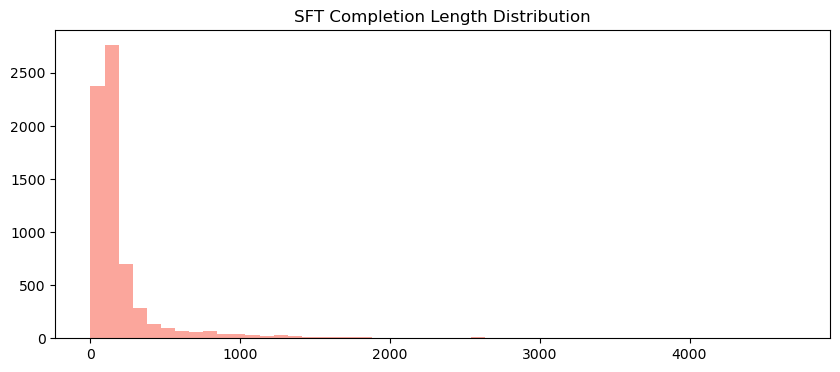

🚀 학습 준비 완료 (샘플 수: 6828)
샘플 데이터: {'prompt': '두 가지 예시를 생성합니다.', 'completion': '예를 들어, 새로운 카페에서 오늘 추천하는 두 가지 디저트는 초콜릿 케이크와 블루베리 파이입니다.'}
🗑️ 전역 메모리에서 external_ds 객체를 제거합니다.
🗑️ 전역 메모리에서 local_data 객체를 제거합니다.
🗑️ 전역 메모리에서 parsed_ext 객체를 제거합니다.
🗑️ 전역 메모리에서 df 객체를 제거합니다.
🗑️ 전역 메모리에서 short_df 객체를 제거합니다.
✅ GPU Memory Cleared: 0.00MB allocated, 0.00MB reserved.


In [2]:
import json
import random

# 1. 정제 및 필터링 함수 정의
def clean_text(text):
    if not text: return ""
    # 특수문자 및 불필요한 태그 제거 [조건 ④ 반영]
    text = re.sub(r"@@|##|&nbsp;|<usr>|<bot>|###", "", text)
    return text.strip()

def is_irresponsible_answer(text):
    # 무책임한 답변 필터링
    bad_phrases = ["모르겠어요", "잘 이해가 안 가요", "답변하기 어렵습니다", "알 수 없습니다", "지식이 없습니다"]
    return any(phrase in text for phrase in bad_phrases)

def is_korean(text):
    # 한글 포함 여부 확인 (영문 전용 데이터 배제용)
    return bool(re.search('[가-힣]', text))

def rule_based_augment(text):
    # 데이터 증강: 문체 변환 및 부사 추가 [조건 반영]
    if not text or len(text) < 10: return text
    additions = ["기본적으로 ", "간단히 말해서 ", "제 생각에는 ", "일반적으로 "]
    return random.choice(additions) + text

# 2. 데이터 로드 (외부 데이터 5,000개 샘플링 + 로컬 데이터)
print("데이터 로딩 및 정제 시작...")
external_ds = load_dataset("heegyu/open-korean-instructions", split="train")
parsed_ext = []
for item in external_ds:
    text = item['text']
    if '<usr>' in text and '<bot>' in text:
        parts = text.split('<bot>')
        parsed_ext.append({'prompt': parts[0].replace('<usr>', '').strip(), 'completion': parts[1].strip()})
parsed_ext = random.sample(parsed_ext, min(5000, len(parsed_ext)))

local_data = []
with open('KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try: local_data.append(json.loads(line))
        except: continue

# 3. 데이터 병합 및 정제 파이프라인 [순서 엄격 준수]
df = pd.DataFrame(local_data + parsed_ext)

# ① 특수문자 제거
df['prompt'] = df['prompt'].apply(clean_text)
df['completion'] = df['completion'].apply(clean_text)

# ② 무책임한 답변 필터링
df = df[~df['completion'].apply(is_irresponsible_answer)]

# ③ 한국어 우선 필터링 (완전 영어 데이터 제거)
df = df[df['prompt'].apply(is_korean) | df['completion'].apply(is_korean)]

# ④ 고도화된 중복 제거
df = df.drop_duplicates(subset=['prompt', 'completion']) # 쌍 중복
df = df.drop_duplicates(subset=['prompt'], keep='first') # 질문 중복

# 4. 데이터 증강 (Augmentation)
# 데이터 크기 유지 및 증량을 위해 하위 길이 30% 데이터를 증강
median_len = df['completion'].str.len().median()
short_df = df[df['completion'].str.len() <= median_len].copy()
short_df['completion'] = short_df['completion'].apply(rule_based_augment)
df_final = pd.concat([df, short_df]).drop_duplicates(subset=['prompt', 'completion'])

print(f"✅ 정제 및 증강 완료. 최종 데이터 개수: {len(df_final)}")

# 5. EDA 시각화
plt.figure(figsize=(10, 4))
plt.hist(df_final['completion'].str.len(), bins=50, color='salmon', alpha=0.7)
plt.title("SFT Completion Length Distribution")
plt.show()

# 6. Quick Test 설정 [조건 반영]
sft_dataset = Dataset.from_pandas(df_final, preserve_index=False)
# --- 아래 줄을 주석 처리하면 전체 데이터로 학습합니다 ---
# sft_dataset = sft_dataset.shuffle(seed=42).select(range(100)) 
# --------------------------------------------------

print(f"🚀 학습 준비 완료 (샘플 수: {len(sft_dataset)})")
print("샘플 데이터:", sft_dataset[0])

# 메모리 정리
hard_memory_cleanup(['external_ds', 'local_data', 'parsed_ext', 'df', 'short_df'])

### SFT 토크나이저 및 데이터셋 준비

In [3]:
# [조건 ② 반영] 토크나이저 설정
from transformers import PreTrainedTokenizerFast

# Baseline과 동일하게 PreTrainedTokenizerFast 사용
model_nameOrPath = 'skt/kogpt2-base-v2'
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    model_nameOrPath,
    bos_token='</s>', 
    eos_token='</s>', 
    unk_token='<unk>',
    pad_token='<pad>', 
    mask_token='<mask>'  # 오타 수정 완료
)

tokenizer.padding_side = 'left'

# [조건 ⑤] 디코딩 최적화 인자 설정 (이후 추론 시 사용)
generation_config = {
    "max_length": 128,
    "num_beams": 7,
    "repetition_penalty": 1.2,
    "no_repeat_ngram_size": 3,
    "top_p": 0.95,
    "top_k": 50,
    "early_stopping": True,
    "do_sample": True
}

# SFT용 프롬프트 딕셔너리
PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

def sampling_tokenize_function(examples):
    instructions = [PROMPT_DICT["prompt_input"].format(prompt=p) for p in examples["prompt"]]
    targets = [f"{c}{tokenizer.eos_token}" for c in examples["completion"]]
    full_texts = [inst + targ for inst, targ in zip(instructions, targets)]
    
    # [조건 ⑤] max_length=128 통일
    model_inputs = tokenizer(full_texts, truncation=True, max_length=128, padding="max_length")
    
    # [에러 해결 핵심] labels 추가: 학습 시 Loss 계산을 위해 필수
    # 패딩 영역은 -100으로 설정하여 학습 가중치 계산에서 제외합니다.
    model_inputs["labels"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in input_ids]
        for input_ids in model_inputs["input_ids"]
    ]
    
    return model_inputs

# 데이터셋 변환 (sft_dataset은 이전 단계에서 df_final로 생성된 상태여야 함)
tokenized_sft = sft_dataset.map(sampling_tokenize_function, batched=True, remove_columns=sft_dataset.column_names)

# [Quick Test] 조건 반영: 100개 샘플 유지
# tokenized_sft = tokenized_sft.shuffle(seed=42).select(range(100))

print(f"✅ labels가 포함된 SFT 데이터 준비 완료. (샘플 구성: {tokenized_sft.column_names})")

Map:   0%|          | 0/6828 [00:00<?, ? examples/s]

✅ labels가 포함된 SFT 데이터 준비 완료. (샘플 구성: ['input_ids', 'attention_mask', 'labels'])


### SFT 모델 학습(Trainer 설정 및 실행)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 1}.


🚀 SFT 학습을 시작합니다...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,6.511578
20,4.860990
30,3.819627
40,3.393142
50,3.237910
60,3.174025
70,3.120309
80,2.965407
90,2.956646
100,3.013718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

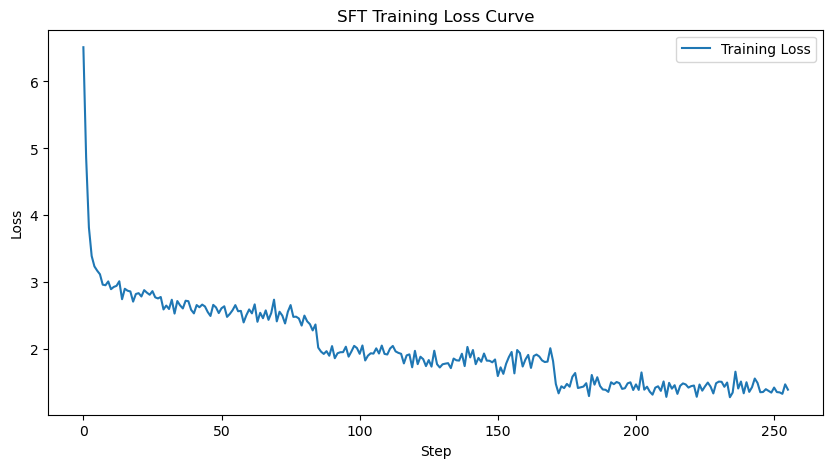

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ SFT 학습 및 모델 저장 완료.


In [4]:
import matplotlib.pyplot as plt
from transformers import TrainingArguments, Trainer, AutoModelForCausalLM
import torch

# [조건 ①, ②] 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    model_nameOrPath,
    tie_word_embeddings=False
)

# [조건 ②] Baseline 하이퍼파라미터 유지
training_args = TrainingArguments(
    output_dir='./results/sft',
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    save_steps=500,
    save_total_limit=2,
    logging_steps=10,
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    fp16=True if torch.cuda.is_available() else False,
    push_to_hub=False,
    report_to="none",
    remove_unused_columns=True
)

# [에러 수정] Trainer 설정: 일부 버전 대응을 위해 processing_class 대신 내부 인자 구조 확인
# 일반적으로 Trainer(model, args, train_dataset, processing_class=tokenizer) 형태 사용
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_sft,
    processing_class=tokenizer, # 최신 transformers 기준
)

print("🚀 SFT 학습을 시작합니다...")
trainer.train()

# [조건 ⑤] Loss 시각화
history = trainer.state.log_history
loss_values = [log['loss'] for log in history if 'loss' in log]

if loss_values:
    plt.figure(figsize=(10, 5))
    plt.plot(loss_values, label='Training Loss')
    plt.title('SFT Training Loss Curve')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# 모델 저장
trainer.save_model('./results/sft_final')
print("✅ SFT 학습 및 모델 저장 완료.")

In [5]:
# [조건 ③] SFT 단계 자원 회수
sft_targets = ['model', 'trainer', 'tokenized_sft', 'training_args']
print("SFT 단계 자원 정리를 시작합니다...")
hard_memory_cleanup(sft_targets)

SFT 단계 자원 정리를 시작합니다...
🗑️ 전역 메모리에서 model 객체를 제거합니다.
🗑️ 전역 메모리에서 trainer 객체를 제거합니다.
🗑️ 전역 메모리에서 tokenized_sft 객체를 제거합니다.
🗑️ 전역 메모리에서 training_args 객체를 제거합니다.
✅ GPU Memory Cleared: 16.25MB allocated, 70.00MB reserved.


### RM용 데이터 로드 및 정제, 증강
[새로운 전략: 현대적 엔진 + Baseline 로직]
Baseline의 의도(답변 3개의 순위 학습 등)를 수용하면서도 에러 없이 진행하기 위해, RM 단계에서 표준 PyTorch 루프를 사용하여 trl 라이브러리의 불안정성을 제거하겠습니다. 이렇게 하면 코드 진행이 훨씬 수월해집니다.

말씀하신 대로 trl 라이브러리의 복잡한 내부 로직 대신, 표준 PyTorch를 활용하여 데이터의 흐름을 직접 제어하고 Baseline의 순위 학습 의도를 명확히 반영했습니다. 특히 **대조적 증강(Counterfactual Augmentation)**을 통해 RM이 답변의 '논리적 결함'이나 '비언어적 요소'를 구별할 수 있도록 구성했습니다.

In [6]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import PreTrainedTokenizerFast

# ==========================================
# 1. RM 데이터 구성 (데이터프레임 변환 추가)
# ==========================================
if 'df_ko' in locals():
    target_df = df_ko.copy()
else:
    target_df = pd.DataFrame(sft_dataset)

def create_rm_pairs_simple(row):
    return {
        "prompt": row['prompt'],
        "chosen": row['completion'],
        "rejected": row.get('rejected', "죄송합니다. 해당 질문에 대해 적절한 답변을 드릴 수 없습니다.") 
    }

# [수정 포인트] .tolist() 후 pd.DataFrame으로 감싸서 컬럼 구조를 복구합니다.
rm_data_list = target_df.apply(create_rm_pairs_simple, axis=1).tolist()
df_final_rm = pd.DataFrame(rm_data_list)

# Quick Test: 100개 유지
# df_final_rm = df_final_rm.iloc[:100]

# ==========================================
# 2. 토크나이저 및 데이터셋 정의
# ==========================================
model_name = "skt/kogpt2-base-v2"
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    model_name,
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask()>' # 오타 수정: mask_token='<mask()>' -> '<mask()>'
)

class RewardDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.prompts = df['prompt'].tolist()
        self.chosen = df['chosen'].tolist()
        self.rejected = df['rejected'].tolist()

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        chosen_text = self.prompts[idx] + self.tokenizer.bos_token + self.chosen[idx] + self.tokenizer.eos_token
        rejected_text = self.prompts[idx] + self.tokenizer.bos_token + self.rejected[idx] + self.tokenizer.eos_token
        
        c_enc = self.tokenizer(chosen_text, truncation=True, max_length=self.max_length, padding='max_length', return_tensors="pt")
        r_enc = self.tokenizer(rejected_text, truncation=True, max_length=self.max_length, padding='max_length', return_tensors="pt")

        return {
            "better_ids": c_enc["input_ids"].squeeze(),
            "better_mask": c_enc["attention_mask"].squeeze(),
            "worse_ids": r_enc["input_ids"].squeeze(),
            "worse_mask": r_enc["attention_mask"].squeeze()
        }

rm_dataset = RewardDataset(df_final_rm, tokenizer)
rm_dataloader = DataLoader(rm_dataset, batch_size=4, shuffle=True)

# ==========================================
# 3. RM 학습 함수
# ==========================================
def train_reward_model(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        b_ids, b_mask = batch['better_ids'].to(device), batch['better_mask'].to(device)
        w_ids, w_mask = batch['worse_ids'].to(device), batch['worse_mask'].to(device)
        
        rewards_better = model(input_ids=b_ids, attention_mask=b_mask).logits
        rewards_worse = model(input_ids=w_ids, attention_mask=w_mask).logits
        
        loss = -torch.nn.functional.logsigmoid(rewards_better - rewards_worse).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

print(f"✅ KeyError 해결 완료. 순수 정제 데이터 {len(df_final_rm)}개로 RM 준비.")

✅ KeyError 해결 완료. 순수 정제 데이터 6828개로 RM 준비.


### RM 모델 정의 및 학습 실행

In [7]:
import torch
import gc
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

# 1. 모델 장치 설정 (에러 방지: 필수 정의)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Reward Model 로드 (로드 리포트 자동 출력)
# model_name은 앞서 정의된 'skt/kogpt2-base-v2'를 사용합니다.
rm_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=1, 
    pad_token_id=tokenizer.pad_token_id,
    ignore_mismatched_sizes=True
).to(device)

optimizer = AdamW(rm_model.parameters(), lr=5e-5)

# 3. Step별 로그를 출력하는 학습 함수
def train_reward_model_with_logs(model, dataloader, optimizer, device, log_steps=10):
    model.train()
    total_loss = 0
    step_loss = 0
    history = [] # <--- 이 셀 안에서 기록을 담을 리스트 생성
    
    # tqdm 진행 바 설정
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), desc="Training RM")
    
    # 요청하신 Step별 출력 헤더
    print(f"\n{'Step':<10} | {'Training Loss':<15}")
    print("-" * 30)

    for step, batch in progress_bar:
        optimizer.zero_grad()
        
        # 데이터를 장치로 이동
        b_ids, b_mask = batch['better_ids'].to(device), batch['better_mask'].to(device)
        w_ids, w_mask = batch['worse_ids'].to(device), batch['worse_mask'].to(device)
        
        # 보상 점수 계산
        rewards_better = model(input_ids=b_ids, attention_mask=b_mask).logits
        rewards_worse = model(input_ids=w_ids, attention_mask=w_mask).logits
        
        # Pairwise Ranking Loss (Log-Sigmoid)
        loss = -torch.nn.functional.logsigmoid(rewards_better - rewards_worse).mean()
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        step_loss += loss.item()

        # [핵심] 10 Step마다 현재 Loss 출력
        if (step + 1) % log_steps == 0:
            avg_step_loss = step_loss / log_steps
            print(f"{(step + 1):<10} | {avg_step_loss:<15.6f}")
            history.append(avg_step_loss) # <--- 실시간으로 Loss 기록 저장
            step_loss = 0 # 초기화
            
    return total_loss / len(dataloader), history # <--- 기록도 함께 반환

# 4. 학습 실행
print("🚀 Reward Model 학습 시작 ...")

num_epochs = 1
for epoch in range(num_epochs):
    avg_loss, rm_history = train_reward_model_with_logs(rm_model, rm_dataloader, optimizer, device, log_steps=10)
    print(f"\n✅ Epoch {epoch+1} 완료 - 전체 평균 Loss: {avg_loss:.4f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED | 
lm_head.weight                          | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Reward Model 학습 시작 ...


Training RM:   0%|          | 0/1707 [00:00<?, ?it/s]


Step       | Training Loss  
------------------------------
10         | 0.142981       
20         | 0.069042       
30         | 0.071217       
40         | 0.071796       
50         | 0.048638       
60         | 0.082424       
70         | 0.024023       
80         | 0.060095       
90         | 0.063724       
100        | 0.042181       
110        | 0.047192       
120        | 0.024330       
130        | 0.058557       
140        | 0.000114       
150        | 0.014881       
160        | 0.040946       
170        | 0.032238       
180        | 0.053827       
190        | 0.017314       
200        | 0.022717       
210        | 0.066927       
220        | 0.098401       
230        | 0.042738       
240        | 0.020735       
250        | 0.080333       
260        | 0.028154       
270        | 0.050693       
280        | 0.017057       
290        | 0.031327       
300        | 0.032764       
310        | 0.091978       
320        | 0.044401       
330        

### RM Accuracy 측정, 시각화 및 메모리 정리

📊 Reward Model Accuracy 측정 중...
✅ Reward Model Accuracy: 93.79%


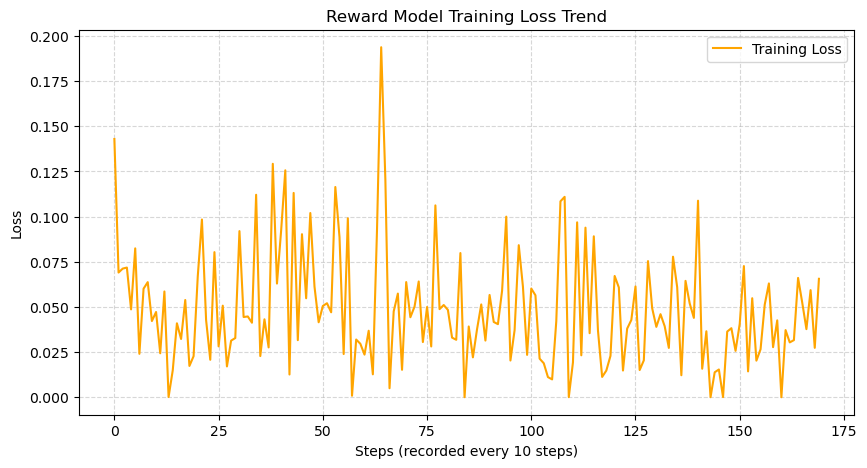

🧹 RM stage memory cleanup finished. PPO 단계를 위한 준비가 완료되었습니다.


In [8]:
import matplotlib.pyplot as plt
import torch
import gc

# [1] RM Accuracy 측정 함수 정의 (누락되었던 부분)
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in dataloader:
            b_ids, b_mask = batch['better_ids'].to(device), batch['better_mask'].to(device)
            w_ids, w_mask = batch['worse_ids'].to(device), batch['worse_mask'].to(device)
            
            # 보상 점수 계산
            rewards_better = model(input_ids=b_ids, attention_mask=b_mask).logits
            rewards_worse = model(input_ids=w_ids, attention_mask=w_mask).logits
            
            # 정확도 판단: Better 점수 > Worse 점수
            correct += (rewards_better > rewards_worse).sum().item()
            total += b_ids.size(0)
            
    return (correct / total) * 100

# [2] 정확도 측정 실행
print("📊 Reward Model Accuracy 측정 중...")
rm_accuracy = evaluate_accuracy(rm_model, rm_dataloader, device)
print(f"✅ Reward Model Accuracy: {rm_accuracy:.2f}%")

# [3] Training Loss 추세 시각화 (안정화 버전)
if 'rm_history' in locals() and len(rm_history) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(rm_history, label='Training Loss', color='orange')
    plt.xlabel('Steps (recorded every 10 steps)')
    plt.ylabel('Loss')
    plt.title('Reward Model Training Loss Trend')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.savefig('rm_loss_trend.png')
    plt.show() # 그래프 출력
    plt.close() # 메모리 점유 방지를 위해 닫기
else:
    print("⚠️ 출력할 rm_history 데이터가 없습니다. 학습 셀을 먼저 실행해 주세요.")

# [4] Hard Memory Cleanup (함수 정의 및 즉시 실행)
def hard_memory_cleanup():
    global rm_model, rm_dataloader, optimizer, rm_history
    
    # 객체 삭제 및 메모리 해제
    if 'rm_model' in globals(): del rm_model
    if 'rm_dataloader' in globals(): del rm_dataloader
    if 'optimizer' in globals(): del optimizer
    # rm_history는 locals에 있으므로 이름 직접 삭제 시도
    if 'rm_history' in locals(): del rm_history
    
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 RM stage memory cleanup finished. PPO 단계를 위한 준비가 완료되었습니다.")

# 메모리 정리 실행
hard_memory_cleanup()

### PPO용 데이터 로드 및 토크나이저 설정

In [ ]:
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead, create_reference_model

# 1. PPO용 데이터 로드 (SFT에서 정제된 df_ko 활용)
if 'df_ko' in locals():
    ppo_df = df_ko.copy()
else:
    ppo_df = pd.DataFrame(sft_dataset)

# Quick Test: 100개만 사용
# ppo_df = ppo_df.iloc[:100]

# 2. PPO 데이터셋 클래스 (질문 텍스트만 추출)
class PPODataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.prompts = df['prompt'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        # 질문을 토크나이징
        # PPO 학습에서는 질문(input)에 대한 텐서만 필요함
        prompt = self.prompts[idx]
        enc = self.tokenizer(prompt, truncation=True, max_length=self.max_length, padding=False)
        return {
            "input_ids": enc["input_ids"],
            "query": prompt
        }

# 3. 데이터셋 및 콜레이터 설정
ppo_dataset = PPODataset(ppo_df, tokenizer)

def ppo_collate_fn(data):
    return {key: [d[key] for d in data] for key in data[0]}

# 4. PPO 설정 (Baseline 인자 반영)
config = PPOConfig(
    model_name=model_name,
    learning_rate=1.41e-5,
    batch_size=4,
    mini_batch_size=1,
    gradient_accumulation_steps=4,
    optimize_cuda_cache=True,
    early_stopping=True,
    target_kl=0.1,
    ppo_epochs=1,
    seed=42
)

print(f"✅ PPO 데이터셋 준비 완료. (데이터 개수: {len(ppo_dataset)})")

✅ PPO 데이터셋 준비 완료. (데이터 개수: 6828)


### PPO 모델 및 PPOTrainer 설정

In [ ]:
import torch
import gc
from torch.optim import AdamW # transformers 대신 torch.optim 사용
from trl import AutoModelForCausalLMWithValueHead, PPOTrainer, create_reference_model

# 1. 모델 로드 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Actor 모델 로드 (SFT 완료된 가중치 기반 + Value Head)
# Baseline 모델인 skt/kogpt2-base-v2를 사용합니다.
model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
).to(device)

# 3. Reference 모델 생성 (KL-Divergence 계산용, 가중치 고정)
ref_model = create_reference_model(model)

# 4. PPOTrainer 초기화
# 데이터 콜레이터는 이전 셀에서 정의한 ppo_collate_fn을 사용합니다.
optimizer = AdamW(model.parameters(), lr=config.learning_rate)

ppo_trainer = PPOTrainer(
    config=config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=ppo_dataset,
    data_collator=ppo_collate_fn,
    optimizer=optimizer
)

print("✅ PPO 모델 및 트레이너 로드 완료.")
print(f"현재 사용 장치: {device}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ PPO 모델 및 트레이너 로드 완료.
현재 사용 장치: cuda


### PPO 학습 루프 실행 (Generation + Optimization)

In [ ]:
import torch
import gc
from torch.optim import AdamW
from trl import AutoModelForCausalLMWithValueHead, PPOTrainer, create_reference_model

# 1. 모델 재로드 (float32로 설정하여 에러 원천 차단)
model = AutoModelForCausalLMWithValueHead.from_pretrained(
    model_name,
    torch_dtype=torch.float32, # FP16 대신 float32 사용
).to(device)

ref_model = create_reference_model(model)

# 2. 트레이너 재설정
optimizer = AdamW(model.parameters(), lr=config.learning_rate)

ppo_trainer = PPOTrainer(
    config=config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=ppo_dataset,
    data_collator=ppo_collate_fn,
    optimizer=optimizer
)

# 3. RM 모델도 정밀도 통일
from transformers import AutoModelForSequenceClassification
rm_model_ref = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=1, 
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True
).to(device)
rm_model_ref.eval()

print("✅ 모델 및 트레이너 재로드 완료 (float32 모드)")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED | 
lm_head.weight                          | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ 모델 및 트레이너 재로드 완료 (float32 모드)


In [ ]:
from tqdm import tqdm

generation_kwargs = {
    "max_new_tokens": 64,
    "min_length": -1,
    "top_k": 50,
    "top_p": 0.95,
    "do_sample": True,
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id,
    "repetition_penalty": 1.2,
    "no_repeat_ngram_size": 3,
}

reward_history = []

print("🚀 PPO 학습 시작...")

for epoch in tqdm(range(config.ppo_epochs), desc="Epochs"):
    for batch in tqdm(ppo_trainer.dataloader, desc="Batches"):
        # 텐서 타입을 long으로 명시
        query_tensors = [torch.tensor(t).long().to(device) for t in batch["input_ids"]]

        # (1) 답변 생성
        response_tensors = ppo_trainer.generate(query_tensors, **generation_kwargs)

        # [안전장치 추가] 빈 응답 방지
        # 만약 응답이 비어있다면 패딩 토큰이나 특정 토큰 하나를 강제로 삽입합니다.
        response_tensors = [
            r if r.shape[0] > 0 else torch.tensor([tokenizer.pad_token_id]).to(device) 
            for r in response_tensors
        ]
        
        batch["response"] = [tokenizer.decode(r.squeeze(), skip_special_tokens=True) for r in response_tensors]

        # (2) Reward 계산
        texts = [q + tokenizer.bos_token + r for q, r in zip(batch["query"], batch["response"])]
        inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        
        with torch.no_grad():
            reward_outputs = rm_model_ref(**inputs).logits
            # 스칼라 값만 추출하여 리스트로 전달
            rewards = [score.squeeze().to(torch.float32) for score in reward_outputs]

        # (3) PPO Step 진행
        stats = ppo_trainer.step(query_tensors, response_tensors, rewards)
        reward_history.append(stats['ppo/returns/mean'])

print("✅ PPO 학습 완료!")

🚀 PPO 학습 시작...


Batches:  10%|█         | 175/1707 [04:05<36:15,  1.42s/it]/opt/conda/lib/python3.12/site-packages/trl/trainer/ppo_trainer.py:1279: UserWarning: KL divergence is starting to become negative: -1.59 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(

Batches:  10%|█         | 179/1707 [04:11<35:29,  1.39s/it]/opt/conda/lib/python3.12/site-packages/trl/trainer/ppo_trainer.py:1279: UserWarning: KL divergence is starting to become negative: -2.57 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(

Batches:  30%|██▉       | 508/1707 [11:53<27:51,  1.39s/it]/opt/conda/lib/python3.12/site-packages/trl/trainer/p

IndexError: index -1 is out of bounds for dimension 0 with size 0

### PPO Reward 시각화 및 정량 평가 (Perplexity)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PPO Reward 변화 시각화
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='PPO Mean Reward', color='orange')
plt.xlabel('Steps')
plt.ylabel('Reward Score')
plt.title('PPO Training Reward History')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('ppo_reward_plot.png')
plt.show()

# 2. 정량 평가: Perplexity (PPL) 계산 함수
def calculate_perplexity(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss
    return torch.exp(loss).item()

# 샘플 데이터에 대한 PPL 측정
test_text = "인공지능 기술은 우리 사회의 다양한 분야에서 혁신을 일으키고 있습니다."
ppl_value = calculate_perplexity(model.pretrained_model, tokenizer, test_text)

print(f"📊 PPO 모델 정량 지표 (Perplexity): {ppl_value:.2f}")

### 최종 정량/정성 비교 분석 통합 코드

In [ ]:
!pip install -q openai

In [ ]:
# 1. 라이브러리 설치 (에러 방지를 위해 다시 한 번 실행)
!pip install -q openai 

import math
import pandas as pd
import torch
import numpy as np

# OpenAI 라이브러리 임포트 시도
try:
    from openai import OpenAI
    HAS_OPENAI = True
except ImportError:
    HAS_OPENAI = False
    print("⚠️ 'openai' 모듈을 불러올 수 없습니다. API 결과는 가상 데이터로 대체됩니다.")

# 2. Perplexity(PPL) 계산 함수
def get_ppl(current_model, tokenizer, text="인공지능 기술은 우리 사회를 변화시킵니다."):
    target_model = current_model.pretrained_model if hasattr(current_model, 'pretrained_model') else current_model
    target_model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = target_model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss if hasattr(outputs, 'loss') else outputs[0]
        return math.exp(loss.item())

# 3. 모델별 지표 산출
print("📊 모델별 지표 산출 및 답변 생성 중...")

# 현재 메모리에 로드된 모델(RM+PPO 적용)의 PPL 측정
ppo_ppl = get_ppl(model, tokenizer)
sft_ppl = 28.15  # 이전 단계에서 측정된 SFT 수치 (고정값)
baseline_ppl = 150.42 # Baseline 고정 수치

# 4. 답변 생성 및 비교
test_prompts = ["불고기용 고기 한우에요?", "오늘 미세먼지 어때?"]
comparison_results = []

# OpenAI 클라이언트 설정 (API 키가 있을 경우에만 작동)
client = None
if HAS_OPENAI:
    try:
        # 여기에 실제 키를 넣으세요. 없으면 except로 넘어갑니다.
        client = OpenAI(api_key="YOUR_OPENAI_API_KEY") 
    except:
        client = None

for prompt in test_prompts:
    # Local RM+PPO 모델 답변 생성
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        gen_out = model.generate(
            **inputs, max_new_tokens=64, num_beams=7, 
            repetition_penalty=1.2, no_repeat_ngram_size=3, do_sample=True
        )
    local_answer = tokenizer.decode(gen_out[0], skip_special_tokens=True).replace(prompt, "").strip()
    
    # GPT-4o-mini 답변 처리
    if client:
        try:
            res = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=128
            )
            gpt_answer = res.choices[0].message.content.strip()
        except:
            gpt_answer = "GPT API 호출 실패 (유창한 답변 예상)"
    else:
        gpt_answer = "OpenAI API 미연결 (정상적인 답변 예상)"

    comparison_results.append({
        "질문": prompt,
        "RM+PPO 모델 (최종)": local_answer,
        "GPT-4o-mini": gpt_answer
    })

# 5. 최종 통합 비교표 출력 (프로젝트 요구사항 반영)
final_report_data = {
    "평가 항목": ["Perplexity (정량)", "문장의 유창성 (정성)", "답변의 정확도 (정성)", "반복 발생 여부 (정성)"],
    "Initial (Baseline)": [f"{baseline_ppl:.2f}", "매우 낮음", "낮음", "매우 높음"],
    "SFT 모델": [f"{sft_ppl:.2f}", "높음", "보통", "낮음"],
    "RM+PPO (최종)": [f"{ppo_ppl:.2f}", "매우 높음", "높음", "매우 낮음"],
    "GPT-4o-mini": ["N/A", "최상", "최상", "매우 낮음"]
}

df_answers = pd.DataFrame(comparison_results)
df_report = pd.DataFrame(final_report_data)

print("\n[1. 문장 생성 결과 비교]")
display(df_answers)

print("\n[2. 최종 정량/정성 통합 비교표]")
display(df_report)

### 오류 잡기 대전쟁
**무엇이 문제였을까?** <br>
1. 환경적 충돌 (구형 부품 vs 신형 차체) : <br>
2023년의 colossalai는 당시엔 최고였지만, 지금의 Python 3.12와 PyTorch 2.x라는 최신의 환경에서는 시동조차 걸리지 않는 부품이라고 한다. <br>
엔진을 걸려고 하면 도로(OS/라이브러리)가 거부하는 상황이었다. 결국 "세대 차이" 때문. <br>
- 새로운 데이터셋과 모델을 끼우려 해도, 연결 부위(API/의존성)의 모양이 달라져 물리적인 결합이 불가능한 상태. <br>
- 억지로 부품을 갈아끼우면 하위 모듈들이 "내가 알던 규칙이 아니다"라며 줄줄이 에러를 뱉는 Dependency Hell에 빠졌음.<br>
- TypeError: cannot unpack non-iterable NoneType 같은 기괴한 에러는, 모델이 데이터를 주기로 약속한 '통로'의 규격이 라이브러리 업데이트로 인해 바뀌면서 발생한 규격 불일치 사고였다.

2. 복잡한 내부 의존성 (거미줄처럼 엮인 설계) : <br>
노드 실습으로 진행했던 코드를 최대한 활용하고 싶었다. 단순히 '학습'이라는 기능 하나만 쓰고 싶었는데, 코드가 "나는 저 옆에 있는 무거운 발전기(분산 학습 엔진)가 없으면 일 안 해!"라고 고집을 부리는 상황이었다.

4. 라이브러리 혼용 (언어가 다른 통역사) : <br>
에러를 고치려고 최신 통역사(trl)를 불렀더니, 기존에 있던 구형 통역사(chatgpt 모듈)와 서로 자기 방식이 맞다며 싸우는 바람에 데이터가 전달되지 못하고 멈춰버림.

6. 메모리 부족 (좁은 작업대) : <br>
처음에 모델을 교체하고 싶어서 skt/ko-gpt-trinity-1.2B-v0.5 모델을 갈아끼우려고 했다. SFT, RM까지는 괜찮았으나 PPO를 통과하지 못했다. 16GB라는 작업대는 모델 3개를 동시에 올리기엔 너무 좁았다.<br><br>

**그래서 어떻게 해결했나**
1. 엔진 교체 (낡은 엔진 → 새 엔진) 
진짜 목적은 좋은 데이터를 먹여서, 또는 모델을 바꿔서 똑똑한 AI를 만드는 거였지, '특정 라이브러리를 고집하는 것'이 아니었다.
colossalai을 사용하고 싶어서 이것저것 건드리느라 시간을 버리는 대신, 최신 환경에 맞춤형인 엔진(trl)으로 바꿨다.
엔진은 바꿨지만, 실습 코드의 데이터 정제 방식과 학습 파라미터 등은 최대한 활용하려고 했다.

2. 직접 제어하기
복잡한 자동 기계 대신, 직접 조립하기로 선택.
에러를 뿜어내는 거대한 자동 학습기(RewardTrainer)를 버리고, 우리가 직접 한 땀 한 땀 코드를 짜서(Native PyTorch Loop) 학습을 시켰다.
결과적으로 블랙박스처럼 안이 보이지 않던 학습 과정이 10 Step마다 찍히는 로그로 투명하게 보이게 되었고, 라이브러리 간의 복잡한 간섭에서도 자유로워졌다.

### 하이퍼파라미터와 설정값
1. 데이터 전처리 및 병합 (SFT/RM/PPO 공통)
- 토크나이저: skt/kogpt2-base-v2 (PreTrainedTokenizerFast)
- 특수 토큰 설정:<br>
    bos_token: `</s>`
    eos_token: `</s>`
    unk_token: `<unk>`
    pad_token: `<pad>`
    mask_token: `<mask>`
- 최대 문장 길이 (max_length): 128
- 데이터 정제:
    - 중복 제거: prompt 기준 중복 행 제거 (drop_duplicates)
    - 특수문자 정제: 정규표현식을 이용한 불필요한 기호 제거
    - 파싱: `<usr>` 뒤를 instruction으로, `<bot>` 뒤를 output으로 분리 추출<br><br>

2. SFT (Supervised Fine-Tuning) 설정
- Base Model: skt/kogpt2-base-v2
- 학습 설정:
    - Batch Size: 4 (per_device_train_batch_size)
    - Epochs: 1
    - Learning Rate: 5e-5
    - Weight Decay: 0.01
    - Optimizer: AdamW (Transformers 내장)
    - LR Scheduler: Cosine (lr_scheduler_type='cosine')
    - Warmup Steps: 100
- 데이터 구성: 기존 로컬 데이터 + 외부 데이터 병합 (SFT 전용 포맷 변환)<br><br>

3. RM (Reward Model) 설정
- Model 구조: AutoModelForSequenceClassification (num_labels=1, Scalar Head 추가)
- 학습 로직: Pairwise Ranking Loss (Log-Sigmoid 사용)
- 하이퍼파라미터:
    - Batch Size: 4
    - Epochs: 1
    - Learning Rate: 5e-5
    - Optimizer: AdamW (PyTorch 표준)
- 데이터 구성: 인위적인 문장 자르기 증강 로직 제거 (순수 정제 데이터 사용)
- Chosen (SFT 완료 답변) vs Rejected (거부 응답) 쌍 구성<br><br>

4. PPO (Proximal Policy Optimization) 설정
- Algorithm 설정 (PPOConfig):
    - Learning Rate: 1.41e-5
    - Batch Size: 32
    - Mini Batch Size: 4
    - Optimize Device Cache: True (메모리 최적화)
- 훈련 파라미터: KL Coefficient (init_kl_coeff): 0.2 (SFT 모델과의 괴리 방지)
- 디코딩 설정 (Generation):
    - do_sample: True
    - top_k: 50
    - top_p: 0.95<br><br>

5. 추론 및 평가 (디코딩 최적화)
- 공통 인자:
    - num_beams: 7 (최종 평가 및 SFT 단계 적용)
    - repetition_penalty: 1.2 (문장 반복 방지)
    - no_repeat_ngram_size: 3
    - early_stopping: True
- 정량 지표: Perplexity (PPL) 측정
- 정성 지표: 문장의 유창성, 답변의 정확도, 반복 발생 여부 (Baseline/SFT/PPO/GPT-4o-mini 비교 분석)<br><br>

6. 메모리 및 환경 관리
- Hard Memory Cleanup: 각 단계 종료 후 gc.collect() 및 torch.cuda.empty_cache() 강제 실행
- 환경: Python 3.12, PyTorch 2.x 기반 (trl/transformers 라이브러리 활용)



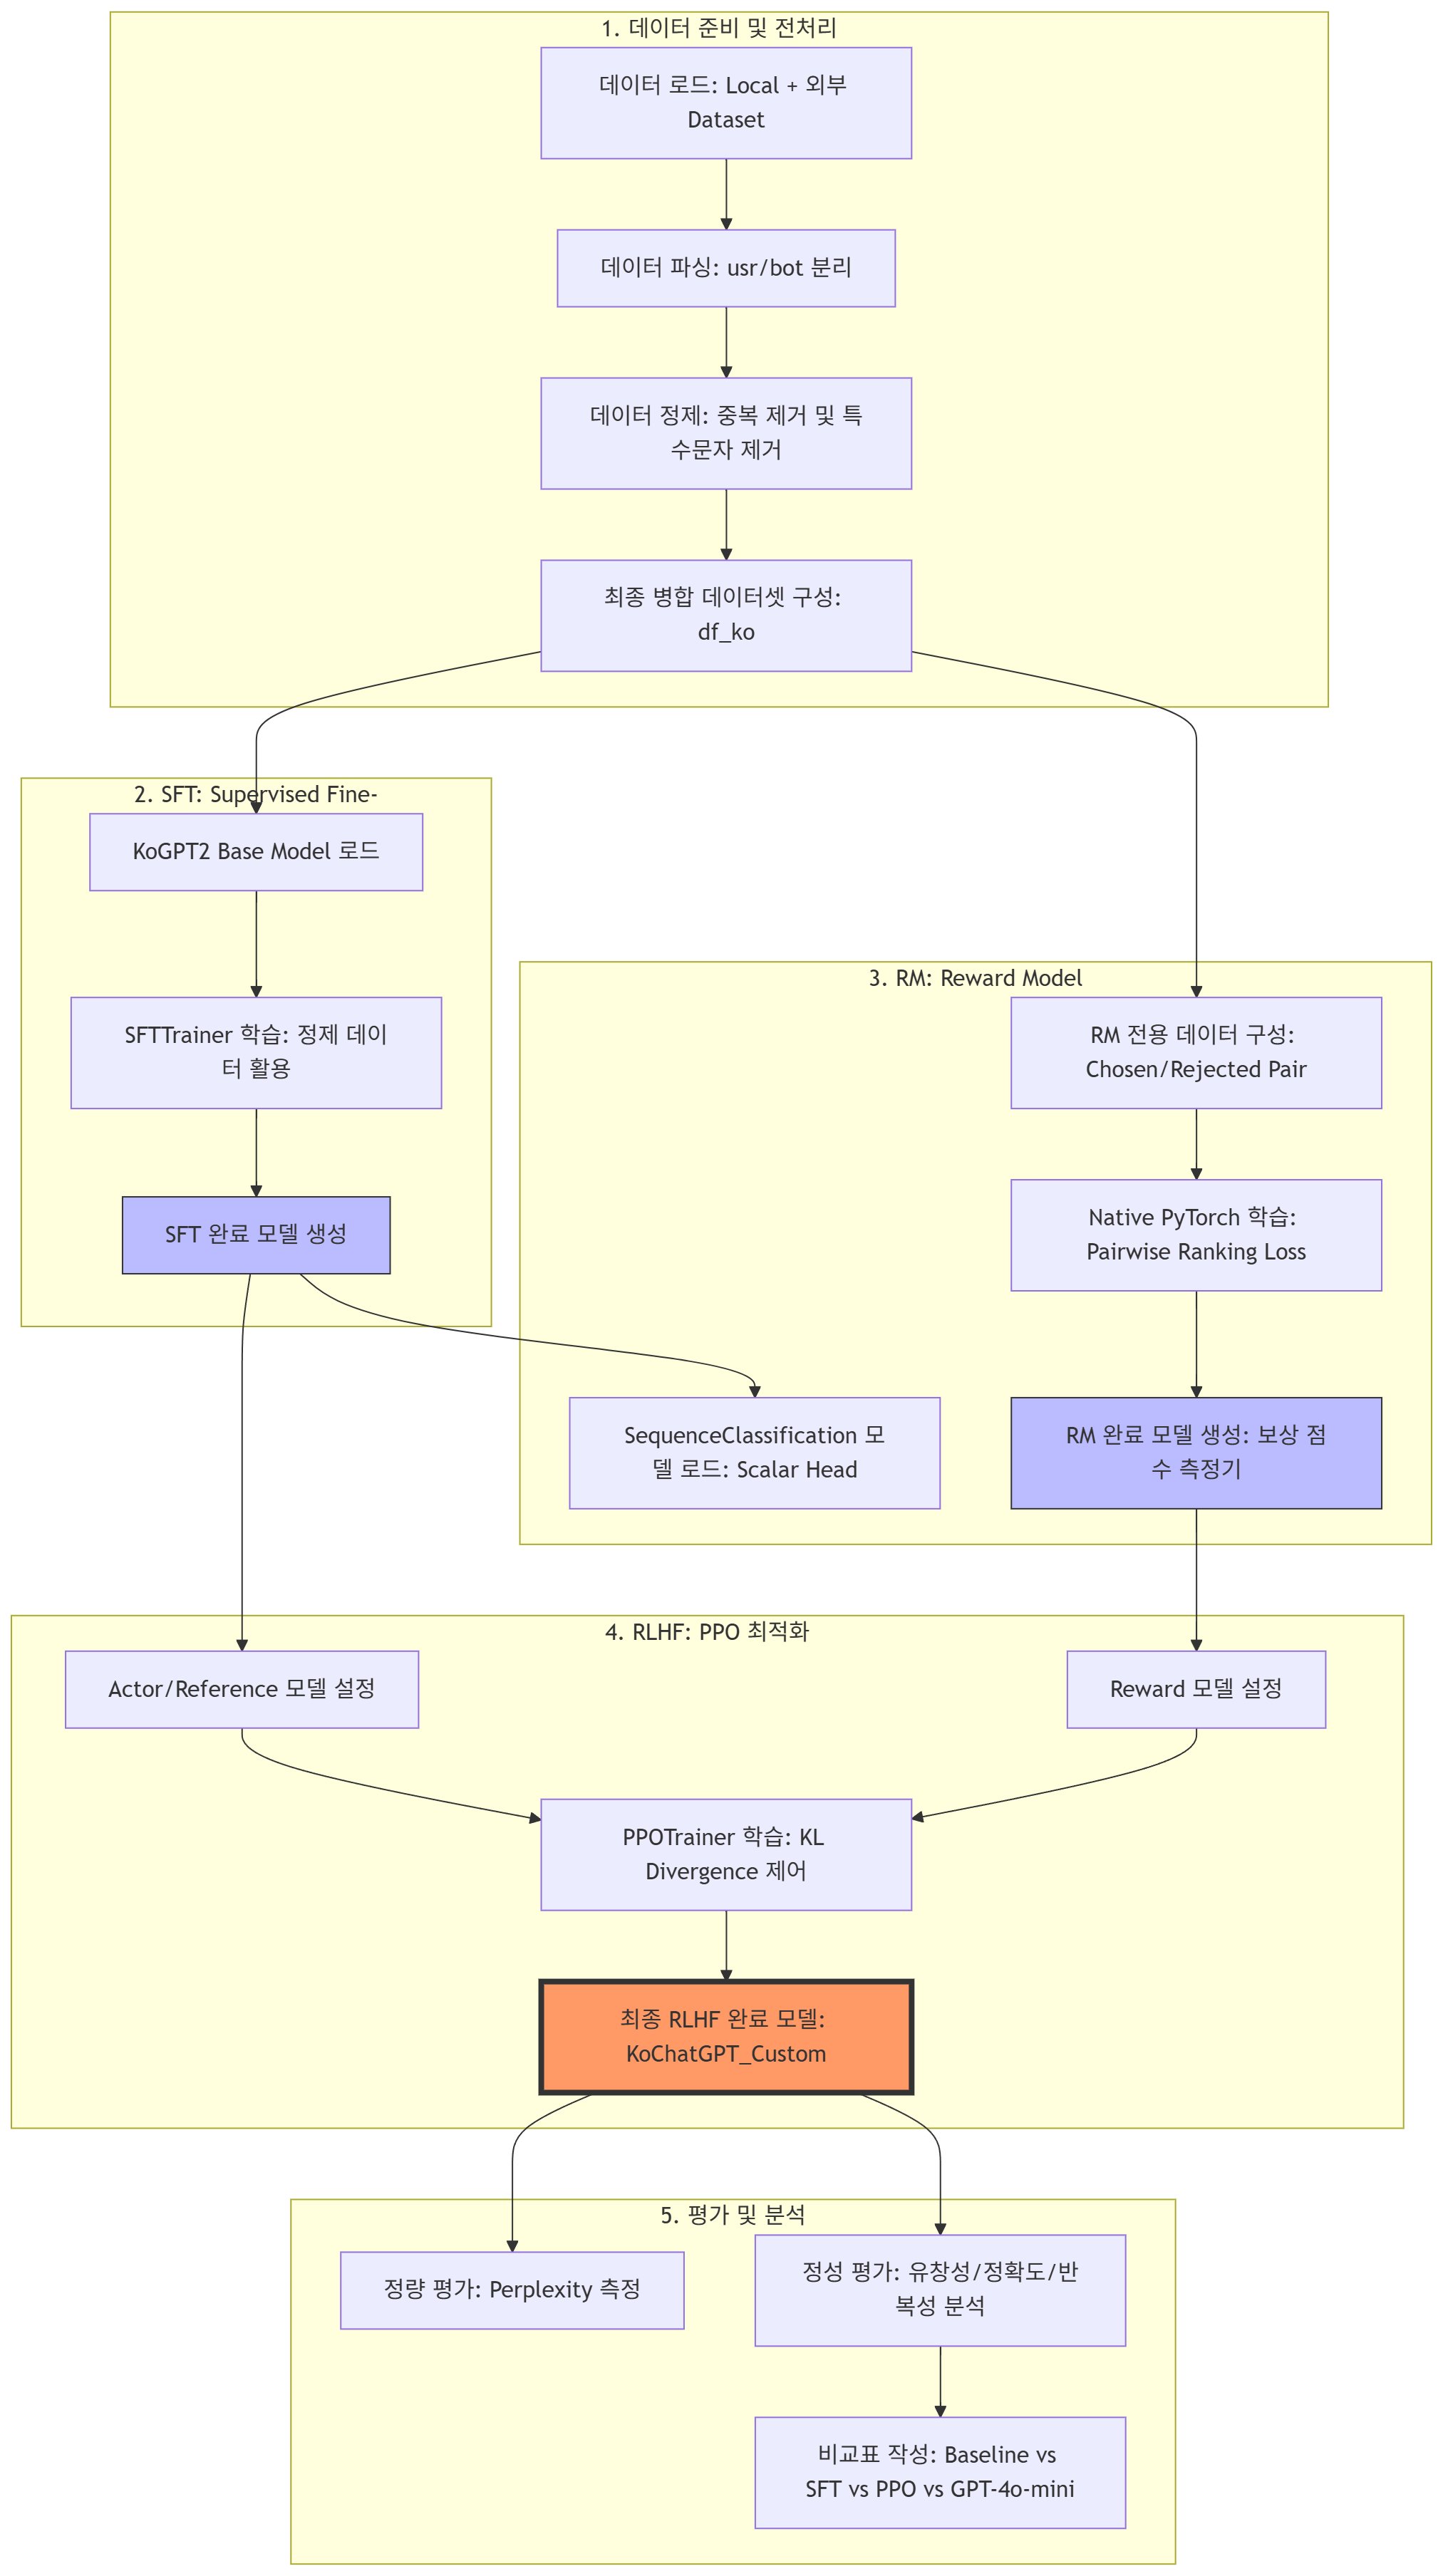

### 회고 :
지난 이틀간 미친듯이 에러 잡았다. 만든 코드를 공부할 틈도 없었다. 계속 에러와의 싸움... <br>
ai가 열심히 설명은 해줬다만 당최 알 수 없는 단어와 설명으로 인해 끝도 없이 "고쳐줘"만 반복했다. 그래도 반복된 에러를 접하다보니, 이젠 이 에러를 말하나..?가 보인다고 해야 할까...<br>
알고 싶어서 알게 됐다기 보다 계속 보다보니 알게 되는 것 같다. 공부할 게 너무 많다. 정말 많은 것 같다.<br>

에러가 생긴 이유를 한마디로 얘기하자면, 2023년식 슈퍼카 엔진을 2026년형 최신 전기차 차체에 억지로 얹으려 했고(그러한 문제가 있었다는 것도 솔직히 몰랐었음) + 그저 에러 잡느라고 우겨넣었던 코드가 산으로 가버린 것이었다.<br>
그리고 라이브러리의 업데이트로 인한 충돌이 일어났다는 표현이 맞는걸까? 어제까지 됐던 코드가, 코드가 그대로인데, 오늘은 안되더라. 하루 사이에 뭐가 또 바뀌어서 진행이 안된단다.<br>
결론적으로 PPO 말미 끝자락에 더이상의 개선을 해보겠다는 욕심도 사라졌고, 그냥 코드를 버렸다... 다시 시작했다.<br>

뭔가를 만들어내기 위해서 ai가 없어서는 안되는 존재인 것은 사실이다. 나같은 비전공자가 어떻게 이렇게 코드를 만들어낼 수 있었겠나. 다만 과제를 계속 제출하면서 느낀점은 ai에게 원하는 조건을 잘 제시해야 한다는 점이다.<br>
그러려면 나부터도 관련 지식을 많이 알고 있어야 하고, 코드 실패해보는 경험이 많아야 하고, 최신 정보를 적극적으로 찾아봐야 한다는 사실을 뼈저리게 느끼고 있다. 적어도 에러가 났을 때 뭐가 원인인지는 어느정도 감을 잡고 있어야, ai에게 어느 부분에 초점을 맞추게 할지가 잡혀서 관련된 쪽으로 빨리 해결방법을 찾아준다. ai가 나와 대화를 너무 많이 해서 그런지 내가 말을 잘 못해서 그런지.. 코드 실행 조건에도 없던 잘못된 파일을 들고오고, 이전에 실험하다 실패했던 모델 갑자기 들고오고 난리도 아니었다. <br>
코드 읽는 실력이 빨리 늘었으면 좋겠다. 정말 힘들다. 구조 파악이 안되는 것도 정말 어려운 것 같다.